In [1]:
%load_ext autoreload
%autoreload 2

import time
from dataclasses import dataclass
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch

from inference.generate import generate
from models.qwen3 import Qwen3

/Users/hyerra/Documents/weft/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_ID = "Qwen/Qwen3-0.6B"
DTYPE = torch.bfloat16
BATCH_SIZE = 2
PROMPT_TOKENS = [128, 512, 1024]
NEW_TOKENS = 32
WARMUP_TOKENS = 4
REPEATS = 5
PERCENTILES = [50, 90, 95, 99]
SEED = 0

# Colors are keyed to a sweep's position in the sweep list, so a sweep keeps its
# color across every chart. Marker shape doubles the encoding for print/CVD.
# Validated colorblind-safe in this order; reorder and the adjacent pairs may not be.
COLORS = ["#4269d0", "#e8833a", "#a463c7", "#3ca951"]
MARKERS = ["o", "s", "^", "D"]

In [3]:
def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def reset_memory(device):
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()


def peak_memory(device):
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated()
    if device.type == "mps":
        return torch.mps.current_allocated_memory()
    return 0

In [4]:
@dataclass
class Run:
    batch_size: int
    prompt_tokens: int
    ttft_s: float
    itl_s: list[float]
    peak_mem: int = 0

    @property
    def ttft_ms(self):
        return 1e3 * self.ttft_s

    @property
    def itl_ms(self):
        return 1e3 * np.array(self.itl_s)

    @property
    def tpot_ms(self):
        return float(np.mean(self.itl_ms))

    @property
    def input_tps(self):
        return self.batch_size * self.prompt_tokens / self.ttft_s

    @property
    def output_tps(self):
        return self.batch_size * 1e3 / self.tpot_ms

    def itl_ms_at(self, percentile):
        return float(np.percentile(self.itl_ms, percentile))

    def output_tps_at(self, percentile):
        return self.batch_size * 1e3 / self.itl_ms_at(percentile)


@dataclass
class Sweep:
    name: str
    device: str
    dtype: str
    batch_size: int
    runs: list[Run]

In [5]:
def measure(model, input_ids, attn_mask, new_tokens, device, stream=generate):
    ttft_s, itl_s = 0.0, []

    sync(device)
    t_prev = time.perf_counter()

    for step, _ in enumerate(stream(model, input_ids, attn_mask, new_tokens)):
        sync(device)
        t_now = time.perf_counter()
        dt, t_prev = t_now - t_prev, t_now

        if step == 0:
            ttft_s = dt
        else:
            itl_s.append(dt)

    return ttft_s, itl_s

In [6]:
device = pick_device()
model = Qwen3.from_pretrained(MODEL_ID, dtype=DTYPE).to(device)
device

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 26158.68it/s]


device(type='mps')

In [7]:
def synthetic_prompt(batch_size, prompt_tokens, vocab_size, device):
    g = torch.Generator().manual_seed(SEED)
    input_ids = torch.randint(0, vocab_size, (batch_size, prompt_tokens), generator=g)
    return input_ids.to(device), torch.ones_like(input_ids).to(device)


def run_sweep(model, name, device, stream=generate):
    vocab_size = model.lm_head.out_features
    runs = []

    print(f"{name}")
    for prompt_tokens in PROMPT_TOKENS:
        input_ids, attn_mask = synthetic_prompt(BATCH_SIZE, prompt_tokens, vocab_size, device)

        measure(model, input_ids, attn_mask, WARMUP_TOKENS, device, stream)

        reset_memory(device)
        ttft_s, itl_s = [], []
        for _ in range(REPEATS):
            t, itl = measure(model, input_ids, attn_mask, NEW_TOKENS, device, stream)
            ttft_s.append(t)
            itl_s.extend(itl)

        run = Run(
            batch_size=BATCH_SIZE,
            prompt_tokens=prompt_tokens,
            ttft_s=float(np.mean(ttft_s)),
            itl_s=itl_s,
            peak_mem=peak_memory(device),
        )
        runs.append(run)
        print(f"  prompt={prompt_tokens:5d}  ttft {run.ttft_ms:8.1f} ms  in {run.input_tps:8.1f} tok/s  out {run.output_tps:6.2f} tok/s")

    return Sweep(name=name, device=str(device), dtype=str(DTYPE), batch_size=BATCH_SIZE, runs=runs)


def summary(sweep):
    print(f"{sweep.name}  {sweep.device}  {sweep.dtype}  batch={sweep.batch_size}")
    print("  prompt  " + "".join(f"{f'p{p}':>20}" for p in PERCENTILES))
    for run in sweep.runs:
        cells = "".join(f"{run.itl_ms_at(p):9.1f}ms{run.output_tps_at(p):7.1f}/s" for p in PERCENTILES)
        print(f"  {run.prompt_tokens:6d}  {cells}")


def compare(sweeps):
    # Every column is a speedup relative to the first sweep, so >1 always means faster:
    # latencies divide the other way round from throughput.
    base, *rest = sweeps
    for sweep in rest:
        print(f"{sweep.name} vs {base.name}  (speedup, >1 is faster)")
        print(f"  {'prompt':>6}  {'ttft':>8}  {'tpot':>8}  {'out tps':>8}")
        for b, r in zip(base.runs, sweep.runs):
            print(f"  {r.prompt_tokens:6d}  {b.ttft_ms / r.ttft_ms:7.2f}x  {b.tpot_ms / r.tpot_ms:7.2f}x  {r.output_tps / b.output_tps:7.2f}x")


def sweep_styles(sweeps):
    return {s.name: dict(color=COLORS[i % len(COLORS)], marker=MARKERS[i % len(MARKERS)],
                         linewidth=2, markersize=7) for i, s in enumerate(sweeps)}


def format_axis(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend()

In [8]:
sweeps = [
    run_sweep(model, "baseline", device, stream=partial(generate, use_cache=False)),
    run_sweep(model, "kv cache", device, stream=partial(generate, use_cache=True)),
]

baseline
  prompt=  128  ttft    169.9 ms  in   1506.4 tok/s  out  10.14 tok/s
  prompt=  512  ttft   4311.9 ms  in    237.5 tok/s  out   1.01 tok/s
  prompt= 1024  ttft   4385.7 ms  in    467.0 tok/s  out   0.48 tok/s
kv cache
  prompt=  128  ttft    190.0 ms  in   1347.4 tok/s  out  28.55 tok/s
  prompt=  512  ttft    622.4 ms  in   1645.2 tok/s  out  19.56 tok/s
  prompt= 1024  ttft   1446.7 ms  in   1415.7 tok/s  out  14.72 tok/s


In [9]:
for sweep in sweeps:
    summary(sweep)
    print()

compare(sweeps)

baseline  mps  torch.bfloat16  batch=2
  prompt                   p50                 p90                 p95                 p99
     128      194.0ms   10.3/s    203.5ms    9.8/s    210.1ms    9.5/s    300.4ms    6.7/s
     512      902.1ms    2.2/s   5538.0ms    0.4/s   6217.1ms    0.3/s   7623.4ms    0.3/s
    1024     1745.3ms    1.1/s   8171.9ms    0.2/s   9015.9ms    0.2/s  10474.4ms    0.2/s

kv cache  mps  torch.bfloat16  batch=2
  prompt                   p50                 p90                 p95                 p99
     128       67.0ms   29.9/s     70.7ms   28.3/s     76.4ms   26.2/s    140.0ms   14.3/s
     512       99.4ms   20.1/s    102.9ms   19.4/s    106.7ms   18.7/s    179.8ms   11.1/s
    1024      134.6ms   14.9/s    138.8ms   14.4/s    140.9ms   14.2/s    151.3ms   13.2/s

kv cache vs baseline  (speedup, >1 is faster)
  prompt      ttft      tpot   out tps
     128     0.89x     2.82x     2.82x
     512     6.93x    19.41x    19.41x
    1024     3.03x    30.38x 

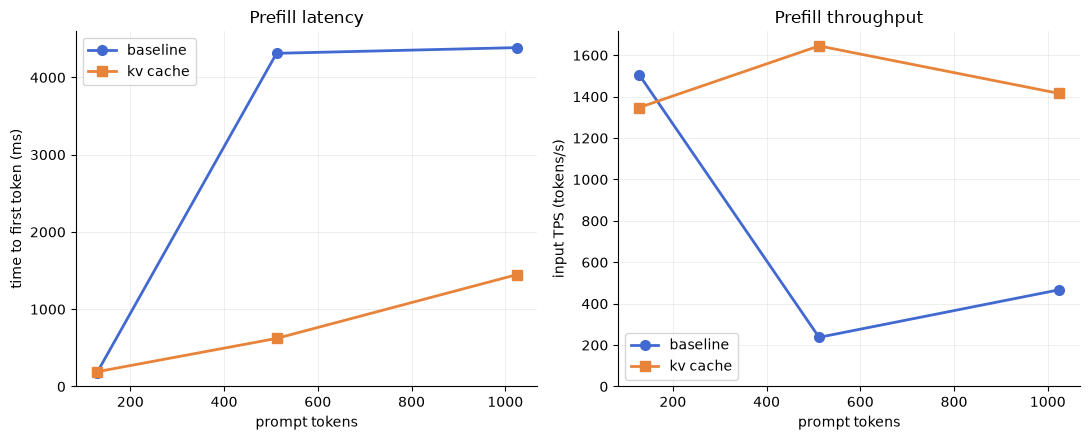

In [10]:
styles = sweep_styles(sweeps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for sweep in sweeps:
    x = [r.prompt_tokens for r in sweep.runs]
    ax1.plot(x, [r.ttft_ms for r in sweep.runs], label=sweep.name, **styles[sweep.name])
    ax2.plot(x, [r.input_tps for r in sweep.runs], label=sweep.name, **styles[sweep.name])

format_axis(ax1, "prompt tokens", "time to first token (ms)", "Prefill latency")
format_axis(ax2, "prompt tokens", "input TPS (tokens/s)", "Prefill throughput")

fig.tight_layout()
plt.show()

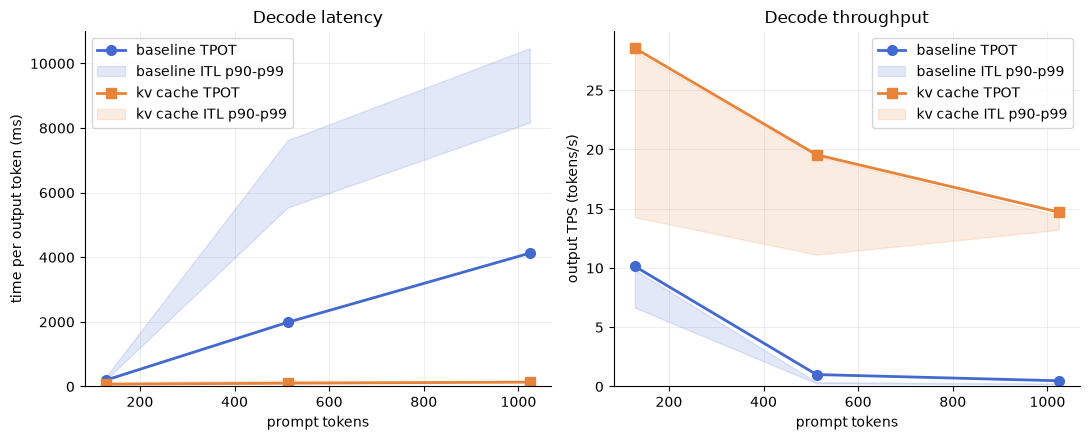

In [11]:
styles = sweep_styles(sweeps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for sweep in sweeps:
    x = [r.prompt_tokens for r in sweep.runs]
    s = styles[sweep.name]

    ax1.plot(x, [r.tpot_ms for r in sweep.runs], label=f"{sweep.name} TPOT", **s)
    ax1.fill_between(x, [r.itl_ms_at(90) for r in sweep.runs], [r.itl_ms_at(99) for r in sweep.runs],
                     alpha=0.15, color=s["color"], label=f"{sweep.name} ITL p90-p99")

    ax2.plot(x, [r.output_tps for r in sweep.runs], label=f"{sweep.name} TPOT", **s)
    ax2.fill_between(x, [r.output_tps_at(99) for r in sweep.runs], [r.output_tps_at(90) for r in sweep.runs],
                     alpha=0.15, color=s["color"], label=f"{sweep.name} ITL p90-p99")

format_axis(ax1, "prompt tokens", "time per output token (ms)", "Decode latency")
format_axis(ax2, "prompt tokens", "output TPS (tokens/s)", "Decode throughput")

fig.tight_layout()
plt.show()

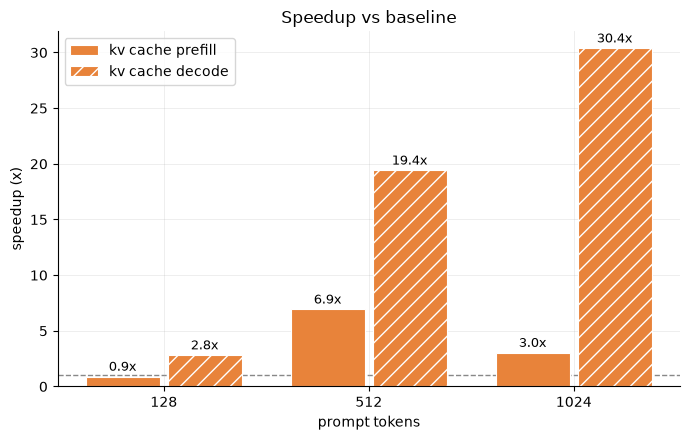

In [12]:
base, *rest = sweeps
styles = sweep_styles(sweeps)

# Color identifies the sweep (same as every other chart); hatch identifies the phase.
METRICS = [
    ("prefill", "", lambda b, r: b.ttft_ms / r.ttft_ms),
    ("decode", "//", lambda b, r: b.tpot_ms / r.tpot_ms),
]

x = np.arange(len(PROMPT_TOKENS))
bars_per_group = len(rest) * len(METRICS)
width = 0.8 / bars_per_group

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, sweep in enumerate(rest):
    for j, (metric, hatch, speedup) in enumerate(METRICS):
        vals = [speedup(b, r) for b, r in zip(base.runs, sweep.runs)]
        offset = (i * len(METRICS) + j - (bars_per_group - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width * 0.9, label=f"{sweep.name} {metric}",
                      color=styles[sweep.name]["color"], hatch=hatch,
                      edgecolor="white", linewidth=0.8)
        ax.bar_label(bars, fmt="%.1fx", padding=2, fontsize=9)

ax.axhline(1.0, color="#888888", linewidth=1, linestyle="--", zorder=0)
ax.set_xticks(x, [str(p) for p in PROMPT_TOKENS])
format_axis(ax, "prompt tokens", "speedup (x)", f"Speedup vs {base.name}")

fig.tight_layout()
plt.show()